In [1]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

In [2]:
ds = fashion_mnist.load_data()

(X_train, y_train),(X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
print(y_train.shape)
print(y_test.shape)


(60000,)
(10000,)


In [5]:
# Normalize pixel 
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [6]:
# Channel Dimension

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

In [7]:
model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

pass

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7888 - loss: 0.5883 - val_accuracy: 0.8556 - val_loss: 0.4100
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8652 - loss: 0.3761 - val_accuracy: 0.8682 - val_loss: 0.3765
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8808 - loss: 0.3286 - val_accuracy: 0.8761 - val_loss: 0.3436
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8920 - loss: 0.2973 - val_accuracy: 0.8913 - val_loss: 0.3038
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9008 - loss: 0.2716 - val_accuracy: 0.8783 - val_loss: 0.3283
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9071 - loss: 0.2542 - val_accuracy: 0.8998 - val_loss: 0.2823
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9146 - loss: 0.2322 - val_accuracy: 0.9018 - val_loss: 0.2692
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9197 - loss: 0.2198 - val_accu

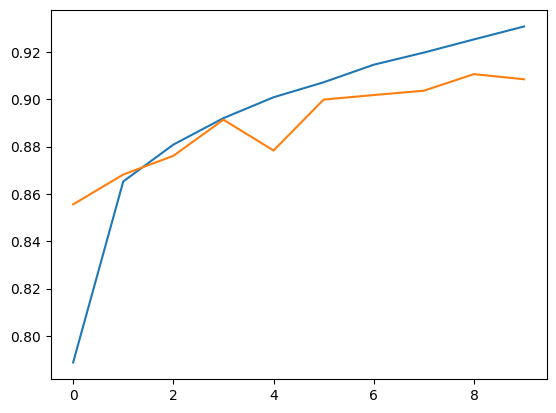

In [10]:
plt.plot(history.history['accuracy'], label=' Training accuracy')
plt.plot(history.history['val_accuracy'], label=' validation accuracy')

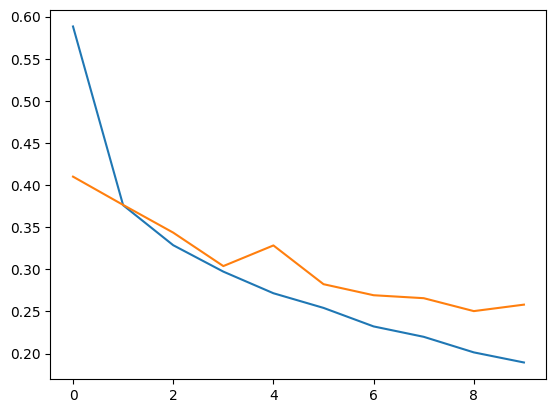

In [11]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='validation loss')

In [12]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [13]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9017


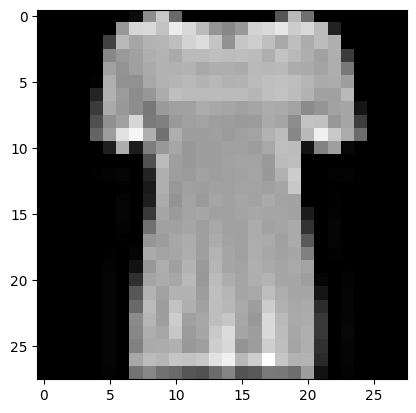

In [14]:
plt.imshow(X_train[10], cmap='gray')
plt.show()